In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install earthengine-api geemap rasterio scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 61.4 MB/s eta 0:00:00


In [3]:
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import os

In [7]:
ee.Authenticate()
ee.Initialize(project='gen-lang-client-0412024487')

In [8]:
california_roi = ee.Geometry.Rectangle([

    -124.5,
    36.5,

    -119.0,
    41.5
])

In [9]:
Map = geemap.Map()

Map.centerObject(california_roi, 6)

Map.addLayer(california_roi, {}, "California ROI")

Map

Map(center=[39.00272451346356, -121.75000000000001], controls=(WidgetControl(options=['position', 'transparent…

In [10]:
dem = ee.Image("USGS/SRTMGL1_003").clip(california_roi)

In [11]:
terrain = ee.Terrain.products(dem)

slope = terrain.select("slope")

In [12]:
Map = geemap.Map()

Map.centerObject(california_roi, 6)

Map.addLayer(
    dem,
    {
        "min": 0,
        "max": 4000,
        "palette": ["blue", "green", "yellow", "red"]
    },
    "California DEM"
)

Map

Map(center=[39.00272451346369, -121.74999999999996], controls=(WidgetControl(options=['position', 'transparent…

In [13]:
Map = geemap.Map()

Map.centerObject(california_roi, 6)

Map.addLayer(
    slope,
    {
        "min": 0,
        "max": 60,
        "palette": ["white", "yellow", "orange", "red"]
    },
    "California Slope"
)

Map

Map(center=[39.00272451346356, -121.75000000000001], controls=(WidgetControl(options=['position', 'transparent…

In [14]:
EXPORT_PATH = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/california/raw/dem"

os.makedirs(EXPORT_PATH, exist_ok=True)

print("California DEM export directory created.")

California DEM export directory created.


In [15]:
geemap.ee_export_image(

    slope,

    filename=f"{EXPORT_PATH}/california_slope.tif",

    scale=1000,

    region=california_roi,

    file_per_band=False
)

Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/PyroRL_Saudi_Project/datasets/california/raw/dem/california_slope.tif


In [16]:
import rasterio

In [17]:
slope_path = f"{EXPORT_PATH}/california_slope.tif"

src = rasterio.open(slope_path)

slope_array = src.read(1)

print(slope_array.shape)

(562, 613)


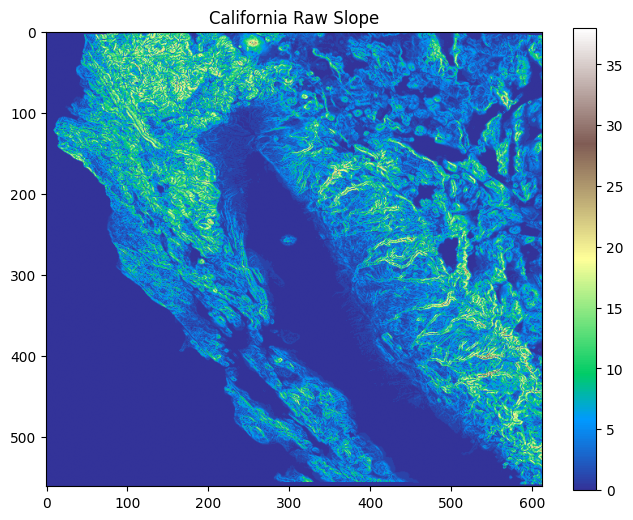

In [18]:
plt.figure(figsize=(8,6))

plt.imshow(slope_array, cmap='terrain')

plt.colorbar()

plt.title("California Raw Slope")

plt.show()

In [19]:
slope_array = np.nan_to_num(slope_array)

In [20]:
def normalize(x):

    return (x - x.min()) / (x.max() - x.min())

In [21]:
slope_norm = normalize(slope_array)

In [22]:
print("Min:", slope_norm.min())

print("Max:", slope_norm.max())

Min: 0.0
Max: 1.0


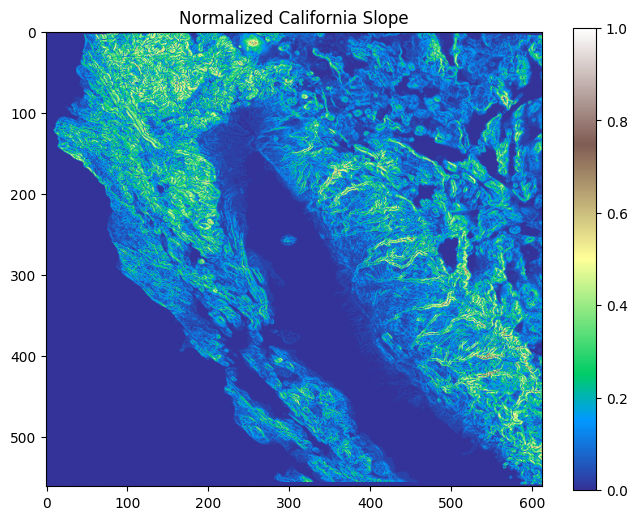

In [23]:
plt.figure(figsize=(8,6))

plt.imshow(slope_norm, cmap='terrain')

plt.colorbar()

plt.title("Normalized California Slope")

plt.show()

In [24]:
from skimage.transform import resize

In [25]:
GRID_32 = (32,32)

GRID_64 = (64,64)

In [26]:
slope_32 = resize(

    slope_norm,
    GRID_32,
    anti_aliasing=True
)

slope_64 = resize(

    slope_norm,
    GRID_64,
    anti_aliasing=True
)

In [27]:
print(slope_32.shape)

print(slope_64.shape)

(32, 32)
(64, 64)


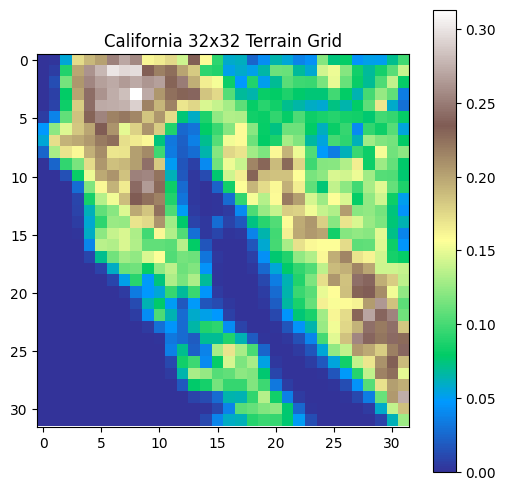

In [28]:
plt.figure(figsize=(6,6))

plt.imshow(slope_32, cmap='terrain')

plt.colorbar()

plt.title("California 32x32 Terrain Grid")

plt.show()

In [29]:
BASE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/california/grids"

os.makedirs(f"{BASE}/32x32", exist_ok=True)

os.makedirs(f"{BASE}/64x64", exist_ok=True)

In [30]:
np.save(

    f"{BASE}/32x32/terrain.npy",

    slope_32
)

print("California 32x32 terrain tensor saved.")

California 32x32 terrain tensor saved.


In [31]:
np.save(

    f"{BASE}/64x64/terrain.npy",

    slope_64
)

print("California 64x64 terrain tensor saved.")

California 64x64 terrain tensor saved.


In [32]:
grid_path = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/california/grids/32x32"

print(os.listdir(grid_path))

['wind_x.npy', 'wind_y.npy', 'temperature.npy', 'humidity.npy', 'fire.npy', 'terrain.npy']


In [33]:
terrain = np.load(

    f"{grid_path}/terrain.npy"
)

print(terrain.shape)

(32, 32)


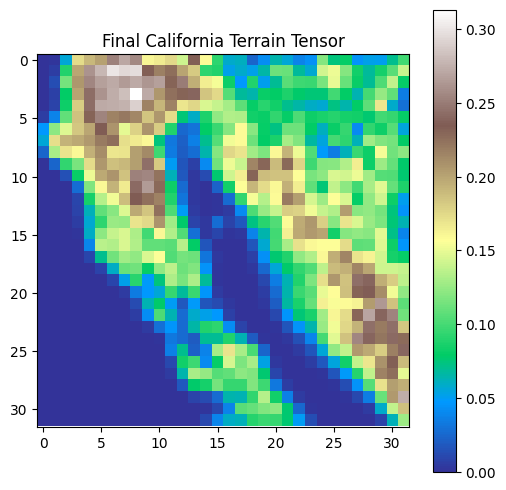

In [34]:
plt.figure(figsize=(6,6))

plt.imshow(terrain, cmap='terrain')

plt.colorbar()

plt.title("Final California Terrain Tensor")

plt.show()